## Alpha and Beta Exponents

The exponents $\alpha$ and $\beta$ characterize how an interface becomes rough in space and time, respectively. Given a height function $h(x,t)$ on a one-dimensional system of length $L$, the interface width, or roughness, is defined as,

$$W(L,t)=\sqrt{\left\langle\left(h(x,t)-\bar{h}(t)\right)^2\right\rangle_x}=\sqrt{\frac{1}{L}\sum_{x=0}^{L-1}\left(h(x,t)-\bar{h}(t)\right)^2}, \quad \bar{h}(t)=\frac{1}{L}\sum_{x=0}^{L-1}h(x,t)$$

Note that we extract the growth exponent $\beta$ in the early time growth regime $t\ll$ where the width grows as

$$W(L, t) \sim t^\beta $$

In longer times where $t \gg$ the width will eventually saturate to the relation

$$W_{\text{sat}}(L) = \lim_{t\rightarrow \infty} W(L, t) \sim L^\alpha$$

Note that the exponents are related as

$$\beta = \frac{\alpha}{z}$$

For the KPZ universality class in one spatial dimension

$$\alpha = \frac{1}{2}, \qquad z = \frac{3}{2}, \qquad \beta = \frac{1}{3}$$

For a diffusive mode

$$\alpha = \frac{1}{2}, \qquad z = 2, \qquad \beta = \frac{1}{4}$$

Note that from the $d-1$ hydrodynamic modes $\phi_\gamma(j,t)$ we can extract a height field given by

$$ h_\gamma(x,t) = \sum_{j=0}^{x-1} \phi_{\gamma}(j,t)$$

So we see that for each hydrodynamic mode, the mode dependent width,

$$ W_\gamma(L,t)=\sqrt{\frac{1}{L}\sum_{x=0}^{L-1}\left|h_\gamma(x,t)-\bar{h}_\gamma(t)\right|^2}, \quad \bar{h}_\gamma(t)=\frac{1}{L}\sum_{x=0}^{L-1}h_\gamma(x,t)$$

Therefore for a three species process in order to extract the two $\alpha$'s we get the slope of the plot for the two hydrodynamic modes

$$\log W_{\gamma, \text{sat}}(L) \quad \text{vs} \quad \log{L}$$

In order to extract the two $\beta$'s we get the slope of the plot for the two hydrodynamic modes

$$\log W_{\gamma}(L, t) \quad \text{vs} \quad \log{t}$$

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import sys
sys.path.append("..")

from src.utils.autocorrelation import autocorrelation
from src.utils.msep import MultiSpeciesExclusionProcess
from src.utils.relaxation_time import relaxation_time

In [2]:
def widths(H):
    mean_H = H.mean(axis=1, keepdims=True)
    W = np.sqrt(np.mean((H - mean_H)**2, axis=1))
    return W

## Determination of Roughness Exponent $\alpha$

Lets start with the totally asymmetric diffusion process where both modes follow the KPZ relation so we expect that $\alpha_1=\alpha_2=1/2$ and $\beta_1=\beta_2=1/3$.

First we start with the determination of the $\alpha$s, we do this by looking at the saturated width for each hydrodynamic mode of an exclusion process. For a $d$ dimensional process we can extract the $d-1$ hydrodynamic modes' height fields with the following function `normal_mode_height_time_series`. 

In order to estimate $\alpha$ we loop through values of `L`, and for each we simulate `n_runs` multi-species exclusion processes, extract the $d-1$ hydrodynamic modes' height fields (with `normal_mode_height_time_series`) for each, convert it to widths and then average (for each mode) over all of the `n_runs` of them in order to get the mean of the width time series. Since we are looking at the saturated behavior we only choose the last `plateau_fraction` fraction of the samples in order to get the saturated (long run) behavior. For instance if we sample `n_samples`, then we say `plateau_fraction = 0.5` or after a `1000` samples has the system reached saturation, this value is pretty arbritrary and whatever gives the best results is chosen. Once we have the saturated width we take the average over it and get for that `L` a value of the average saturated width. Plotting the log of the length vs the log of the saturated width for the $n$th hydrodynamic mode gives a slope of $\alpha_n$.

In [3]:
dimension = 3
density = [1/3, 1/3, 1/3]
rates = np.triu(np.ones((3, 3), dtype=np.float64), k=1) # upper triangular, totally asymmetric diffusion

L_values = np.arange(30, 300, 30)

n_runs = 10              # number of runs per length (we average over them) 
n_samples = 2000         # number of samples when we get the height time series
sample_every = 10        # skip every `sample_every` to save space and time 
plateau_fraction = 0.5   # fraction of samples to skip until "saturation" (this is pretty arbritrary)

In [4]:
def estimate_saturated_widths(L):
    W_sat_runs = []

    for run in range(n_runs):
        proc = MultiSpeciesExclusionProcess(dimension=dimension, density=density, rates_matrix=rates, length=L, shuffle=True)
        h = proc.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every) # shape: (n_samples, L+1, d-1)
        W = widths(h) # shape: (n_samples, d-1)

        start_index = int((1.0 - plateau_fraction) * n_samples)
        W_plateau = W[start_index:, :]
        W_sat = W_plateau.mean(axis=0)
        
        W_sat_runs.append(W_sat)

    W_sat_mean = np.array(W_sat_runs).mean(axis=0)

    return W_sat_mean

In [5]:
W1_sat = []
W2_sat = []

for L in L_values:
    W_sat_mean = estimate_saturated_widths(L)

    W1_sat.append(W_sat_mean[0])
    W2_sat.append(W_sat_mean[1])

logL = np.log(L_values)

logW1 = np.log(np.array(W1_sat))
logW2 = np.log(np.array(W2_sat))

alpha1, c1 = np.polyfit(logL, logW1, 1)
alpha2, c2 = np.polyfit(logL, logW2, 1)

print("Estimated roughness exponents:")
print(f"alpha_1 = {alpha1:.6f}")
print(f"alpha_2 = {alpha2:.6f}")

Estimated roughness exponents:
alpha_1 = 0.497143
alpha_2 = 0.493239


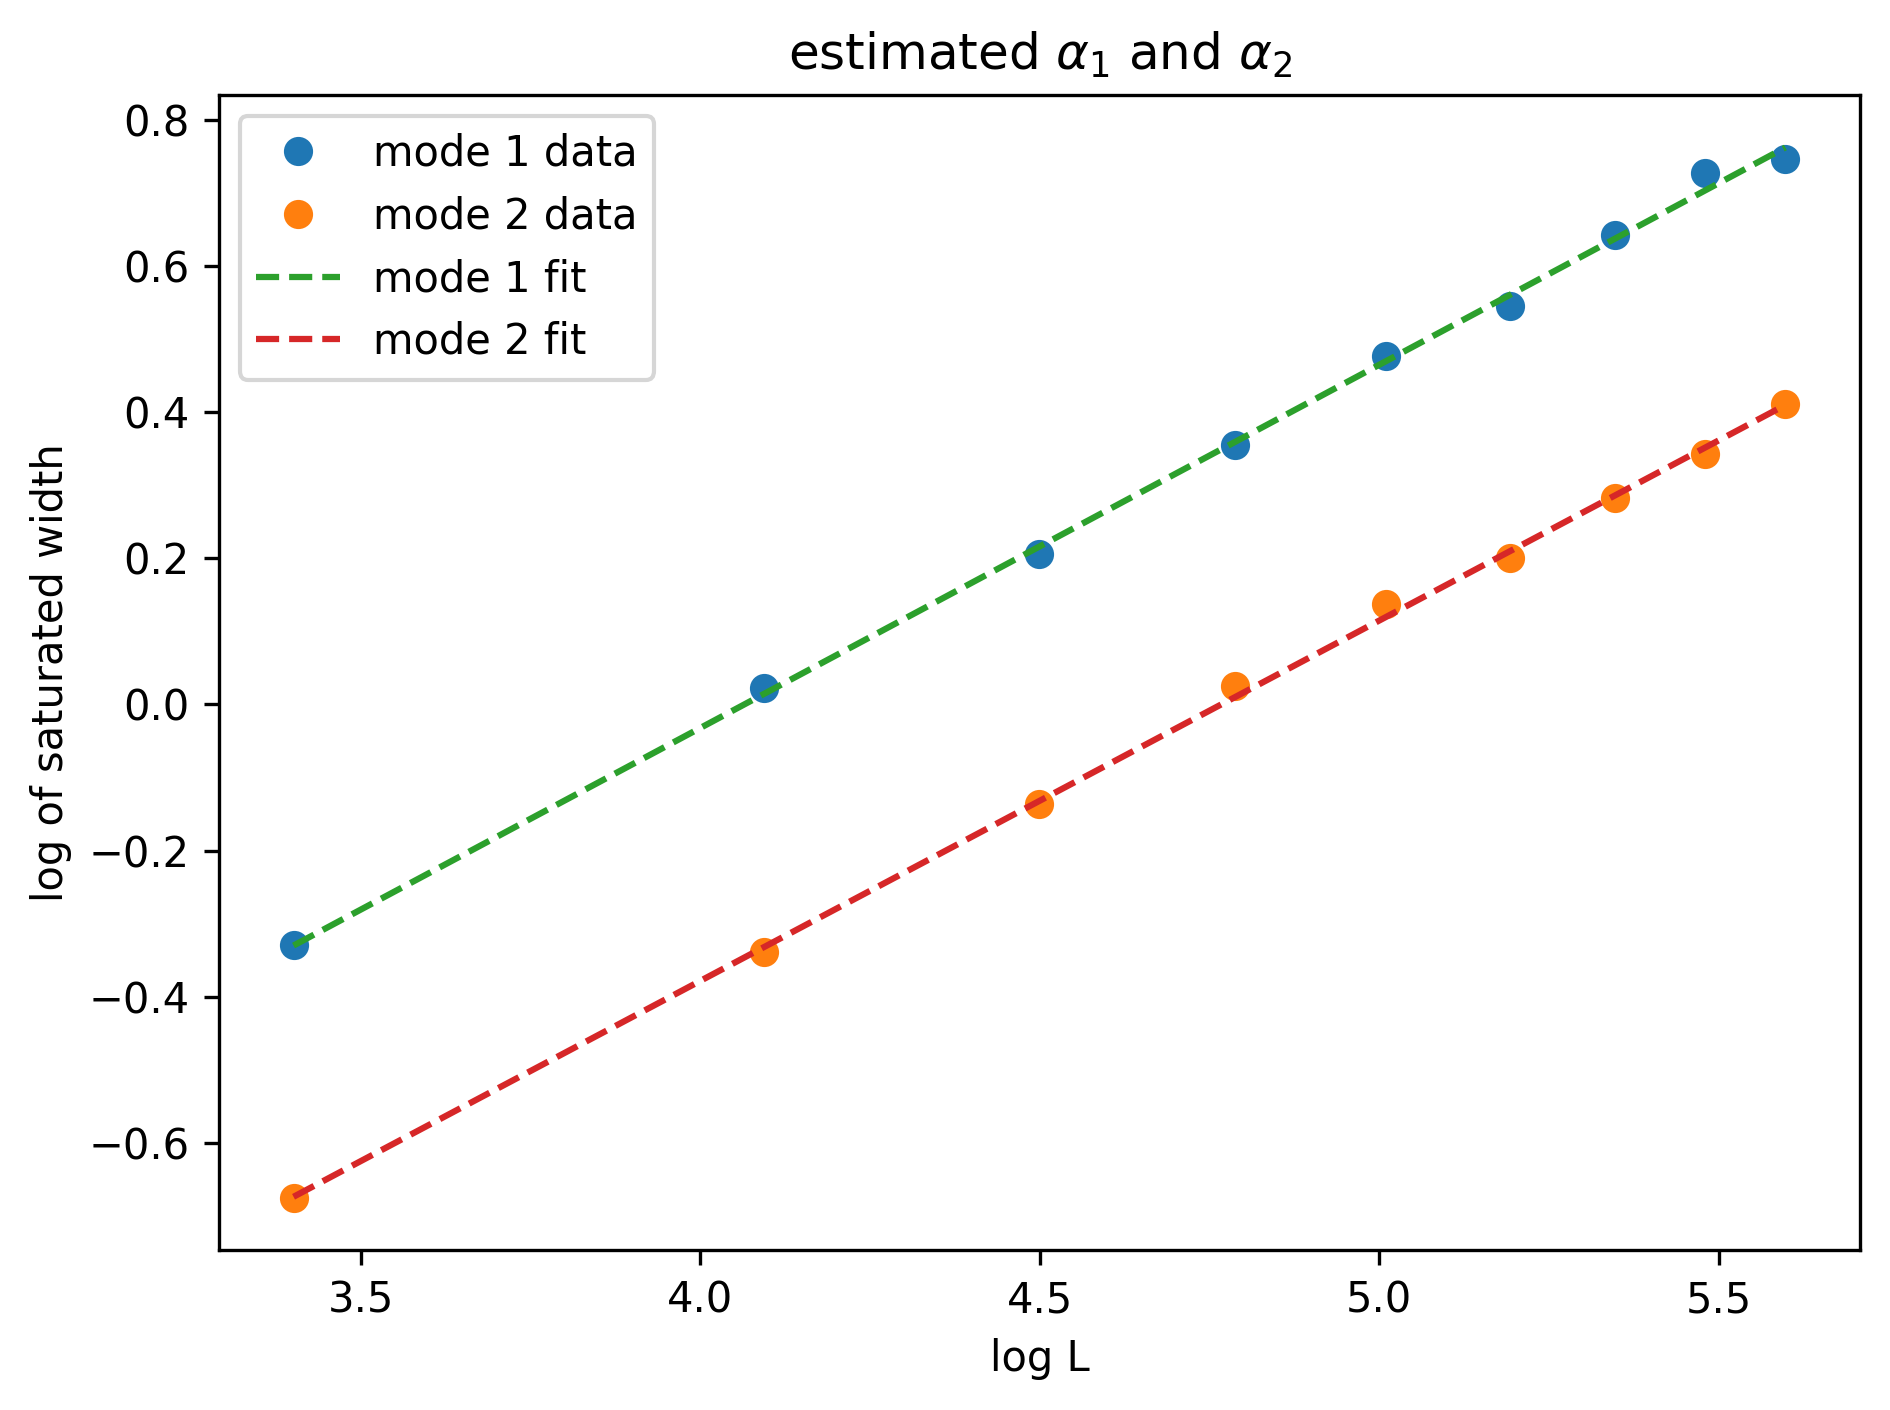

In [6]:
plt.figure(dpi=300)

plt.plot(logL, logW1, "o", label=r"mode 1 data")
plt.plot(logL, logW2, "o", label=r"mode 2 data")

fit_1 = alpha1*logL + c1
fit_2 = alpha2*logL + c2

plt.plot(logL, fit_1, "--", label="mode 1 fit")
plt.plot(logL, fit_2, "--", label="mode 2 fit")

plt.xlabel("log L")
plt.ylabel("log of saturated width")
plt.title(rf"estimated $\alpha_1$ and $\alpha_2$")

plt.legend()
plt.tight_layout()
plt.show()

## Determination of Growth Exponent $\beta$

To calculate the $\beta$s we chose a value for `L` and simulated `n_runs` independent multi-species exclusion processes. Note however that the initial condition is set to an equally spread distribution, such as for three species,

$$ 0, 1, 2, 0, 1, 2, \cdots $$

rather than a randomly shuffled configuration. We do this because $\beta$ measures the early time growth of the roughness,

$$W_\gamma(L,t) \sim t^{\beta_\gamma},$$

starting from a relatively smooth initial interface. If the initial condition is random, then the height field is already rough at time $t=0$. In that case the width is already close to its saturated value, so there is very little visible growth in time. This would make the slope of the log vs log plot close to zero. The equally spread initial condition is therefore used to make the initial normal mode height profiles as flat as possible, so that the growth regime can actually be observed.

After we initialize the process we extract the $d-1$ hydrodynamic modes' height fields (with `normal_mode_height_time_series`) for each, convert it to widths and then average (for each mode) over all of the `n_runs` to get the mean of the width time series. 

Note that the log of the time (steps) vs the log of the width should yeild a plot with the slope of $\beta$ however this is pre saturation, the difficulty is chosing the values of time over what to run the fit that doesn't go into the saturation regime where the slope will not be $\beta$ which is why we define values over which only the fit should be done `fit_t_min` and `fit_t_max`.

In [55]:
rates = np.array([
        [0.0, 0.1, 1.0],
        [2.1, 0.0, 2.1],
        [1.0, 0.1, 0.0]
    ])

In [56]:
L = 900           # length of chain

n_runs = 500      # number of times multi-species exclusion process is created 
n_samples = 500   # number of samples when we get the height time series, note it doesn't matter what `n_samples` is above `fit_t_max` for beta calculation 
sample_every = 1  # sample every when getting the height time series

fit_t_min = 30    # minimum t value for fit
fit_t_max = 300   # maximum t value for fit

In [57]:
# creates chain 0,1,2,0,1,2,0,1,2, ...

def equal_spread_chain(L):
    if L % 3 != 0:
        raise ValueError("needs to be divisible by 3 :) ")

    chain = np.zeros(L, dtype=np.int32)

    for j in range(L):
        chain[j] = j % 3

    return chain

In [58]:
W_runs = []

for run in range(n_runs):
    process = MultiSpeciesExclusionProcess(dimension=dimension, density=density, rates_matrix=rates, length=L, shuffle=False)
    process.set_chain(equal_spread_chain(L).tolist())
    h = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)
    W = widths(h)

    W_runs.append(np.asarray(W))

W_mean = np.array(W_runs).mean(axis=0)

W1 = W_mean[:, 0]
W2 = W_mean[:, 1]

times = np.arange(n_samples) * sample_every
positive = times > 0

times_pos = times[positive]
W1_pos = W1[positive]
W2_pos = W2[positive]

fit_mask = (times_pos >= fit_t_min) & (times_pos <= fit_t_max)

t_fit = times_pos[fit_mask]
W1_fit_data = W1_pos[fit_mask]
W2_fit_data = W2_pos[fit_mask]

logt_fit = np.log(t_fit)

logw1 = np.log(W1_fit_data)
logw2 = np.log(W2_fit_data)

beta1, c1 = np.polyfit(logt_fit, logw1, 1)
beta2, c2 = np.polyfit(logt_fit, logw2, 1)

print("Estimated growth exponents:")
print(f"beta_1 = {beta1:.6f}")
print(f"beta_2 = {beta2:.6f}")

Estimated growth exponents:
beta_1 = 0.244143
beta_2 = 0.308868


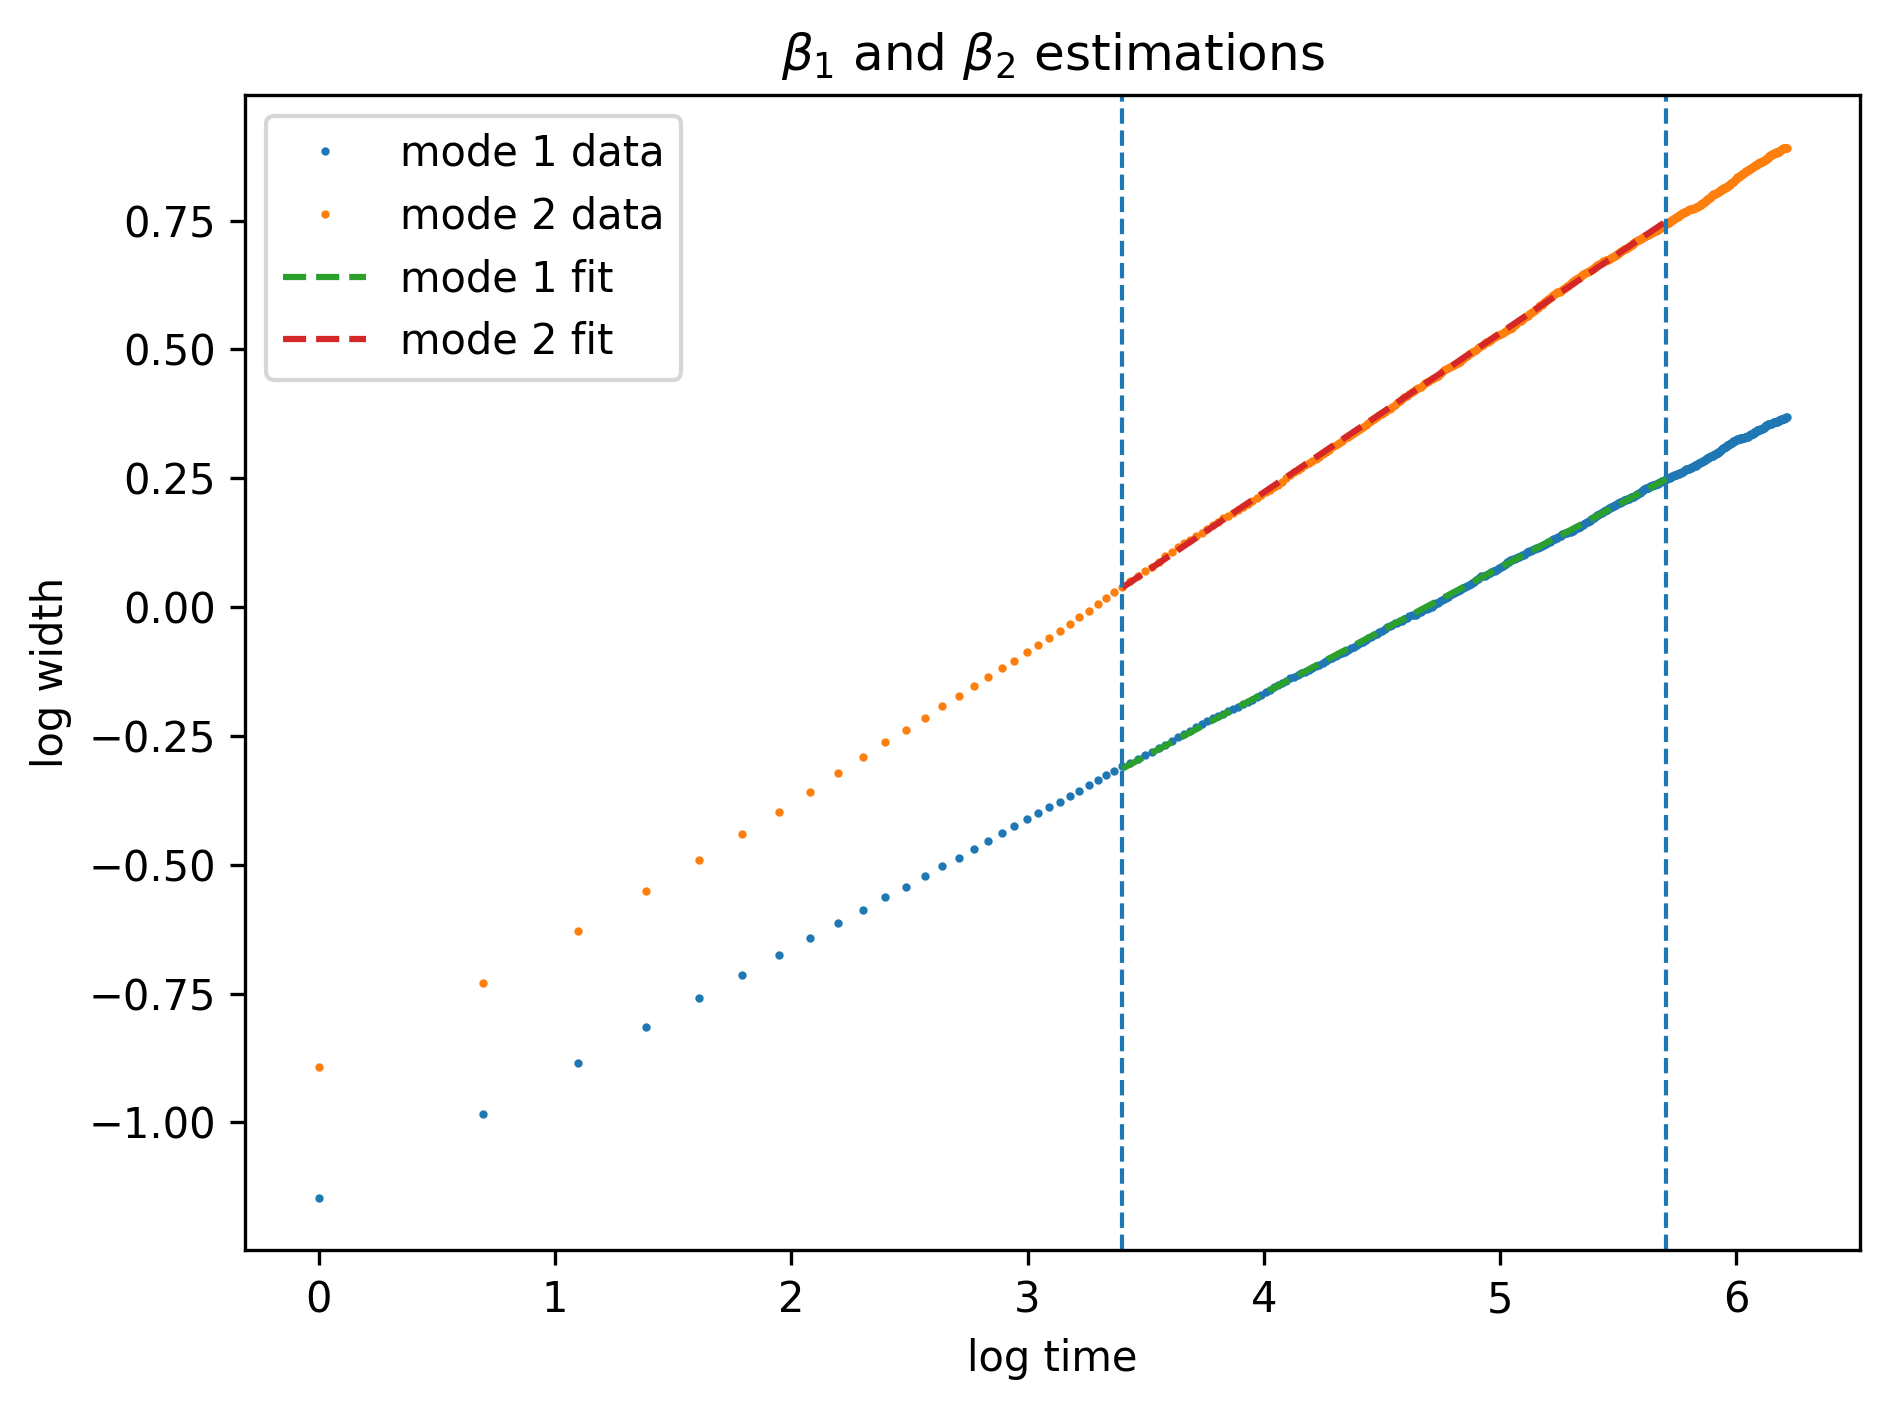

In [59]:
plt.figure(dpi=300)

plt.plot(np.log(times_pos), np.log(W1_pos), "o", markersize=1, label=r"mode 1 data")
plt.plot(np.log(times_pos), np.log(W2_pos), "o", markersize=1, label=r"mode 2 data")

fit_1 = beta1*logt_fit + c1
fit_2 = beta2*logt_fit + c2

plt.plot(logt_fit, fit_1, "--", label="mode 1 fit")
plt.plot(logt_fit, fit_2, "--", label="mode 2 fit")

plt.axvline(np.log(fit_t_min), linestyle="--", linewidth=1) 
plt.axvline(np.log(fit_t_max), linestyle="--", linewidth=1)

plt.xlabel("log time")
plt.ylabel("log width")
plt.title(fr"$\beta_1$ and $\beta_2$ estimations")

plt.legend()
plt.tight_layout()
plt.show()